# **Projeto de Graduação em Computação II [2026-Q1]**

Universidade Federal do ABC

Orientador Carlos da Silva dos Santos

### **EQUIPE**

---

Caio Cardoso Dos Santos - RA: 11202021632

Victor Ravazio de Lima - RA: 11201920941

### **IMPLEMENTAÇÃO**
---

In [ ]:
# modulo para importar dataset a partir de um link
!pip install gdown

In [ ]:
#Bibliotecas
import pandas as pd
import numpy as np
from google.colab import files
import gdown
import matplotlib.pyplot as plt
import random
import seaborn as sns

In [ ]:
#Variaveis de controle
anotado = 100
# num_replys_anotados = 150
# num_quotes_anotados = 150
# num_originals_anotados = 150

In [ ]:
# baixando dataset para o collab
import gdown

file_class_caio = "1lM2oD3feMLsXeX-i6LqAtj3_syH-Swuu"
file_class_victor = "1G-TC7qDMpJyrGdfqsZgr3yFEegLr0dcB"
url_1 = f"https://drive.google.com/uc?id={file_class_caio}"
url_2 = f"https://drive.google.com/uc?id={file_class_victor}"

gdown.download(url_1, "cloroquina_anotado_caio.csv", quiet=False)
gdown.download(url_2, "cloroquina_anotado_victor.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1C5adI1xq00fW3HVTWbafQJWj5NapGOkG
To: /content/Aborto_anotado_caio.csv
100%|██████████| 177k/177k [00:00<00:00, 56.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1G-TC7qDMpJyrGdfqsZgr3yFEegLr0dcB
To: /content/Aborto_anotado_victor.csv
100%|██████████| 177k/177k [00:00<00:00, 74.7MB/s]


'Aborto_anotado_victor.csv'

In [ ]:
#carregando o dataset
df_caio = pd.read_csv ("cloroquina_anotado_caio.csv")
df_victor = pd.read_csv ("cloroquina_anotado_victor.csv")

In [ ]:
#numero total de instancias no dataset
df_caio.shape

(600, 6)

In [ ]:
#numero total de instancias no dataset
df_victor.shape

(600, 6)

In [ ]:
df_caio.head(20)

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,"Estamos em 2020 século 21, as mulheres ainda n...","Qd vc abre a hastag #AbortoNao, a unica coisa ...",0,0.029973,0.970027,0.0
1,#AbortoNao Jamais ! Sim a vida .,"Vc é contra o aborto por se declarar pró vida,...",0,0.035262,0.964738,1.0
2,#AbortoNunca ENTENDAM quando a pessoa é #Abort...,vcs falam #AbortoNao como se existisse um méto...,0,0.035714,0.964286,0.0
3,Alguém pode me explicar quem levantou a pauta ...,Se vc vem opinar numa tag feminina sendo contr...,0,0.038099,0.961901,0.0
4,Aborto não é método contraceptivo!antes de esc...,Vai caça o que fazer e deixa as mulheres escol...,1,0.038269,0.961731,1.0
5,Pelo simples fato de que matar uma vida humana...,@ Vida é a partir do embrião.E embrião é vida....,1,0.040479,0.959521,1.0
6,"Bagaço pqp, eu nao estou gravido pq sou homem,...",#abortonao. Se você defende que a mulher faça ...,1,0.041120,0.958880,1.0
7,#AbortoSim ELAS QUE DECIDEM !,"Ai que inferno, é vc que está com o feto no út...",0,0.041762,0.958238,-1.0
8,O mais engraçado é que a maioria é homem que v...,a mulher tem a escolha de querer abortar ou nã...,0,0.042705,0.957295,0.0
9,"""Ah, mas você vai matar uma vida"" Oh seus band...",não é melhor usar preservativo e outros método...,0,0.042775,0.957224,1.0


In [ ]:
df_victor.head(20)

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,"Estamos em 2020 século 21, as mulheres ainda n...","Qd vc abre a hastag #AbortoNao, a unica coisa ...",0,0.029973,0.970027,0.0
1,#AbortoNao Jamais ! Sim a vida .,"Vc é contra o aborto por se declarar pró vida,...",0,0.035262,0.964738,1.0
2,#AbortoNunca ENTENDAM quando a pessoa é #Abort...,vcs falam #AbortoNao como se existisse um méto...,0,0.035714,0.964286,0.0
3,Alguém pode me explicar quem levantou a pauta ...,Se vc vem opinar numa tag feminina sendo contr...,0,0.038099,0.961901,1.0
4,Aborto não é método contraceptivo!antes de esc...,Vai caça o que fazer e deixa as mulheres escol...,1,0.038269,0.961731,1.0
5,Pelo simples fato de que matar uma vida humana...,@ Vida é a partir do embrião.E embrião é vida....,1,0.040479,0.959521,1.0
6,"Bagaço pqp, eu nao estou gravido pq sou homem,...",#abortonao. Se você defende que a mulher faça ...,1,0.041120,0.958880,1.0
7,#AbortoSim ELAS QUE DECIDEM !,"Ai que inferno, é vc que está com o feto no út...",0,0.041762,0.958238,0.0
8,O mais engraçado é que a maioria é homem que v...,a mulher tem a escolha de querer abortar ou nã...,0,0.042705,0.957295,0.0
9,"""Ah, mas você vai matar uma vida"" Oh seus band...",não é melhor usar preservativo e outros método...,0,0.042775,0.957224,1.0


# **Analise Exploratória**

In [ ]:
# restrigindo por quantidade anotada
df_caio = df_caio.iloc[:anotado,:]
df_caio['Conflict'] = df_caio['Conflict'].astype(int) #convertendo valores para inteiros
df_victor = df_victor.iloc[:anotado,:]
df_victor['Conflict'] = df_victor['Conflict'].astype(int)

In [ ]:
#separando por classe

In [ ]:
df_caio

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,"Estamos em 2020 século 21, as mulheres ainda n...","Qd vc abre a hastag #AbortoNao, a unica coisa ...",0,0.029973,0.970027,0
1,#AbortoNao Jamais ! Sim a vida .,"Vc é contra o aborto por se declarar pró vida,...",0,0.035262,0.964738,1
2,#AbortoNunca ENTENDAM quando a pessoa é #Abort...,vcs falam #AbortoNao como se existisse um méto...,0,0.035714,0.964286,0
3,Alguém pode me explicar quem levantou a pauta ...,Se vc vem opinar numa tag feminina sendo contr...,0,0.038099,0.961901,0
4,Aborto não é método contraceptivo!antes de esc...,Vai caça o que fazer e deixa as mulheres escol...,1,0.038269,0.961731,1
...,...,...,...,...,...,...
95,Vc n pode ser comunista e ao mesmo tempo defen...,Muito menos se dizer cristã e feminista. #Abor...,2,0.138647,0.861353,0
96,#AbortoNao Aborto é caro Não quer ter filho?...,Se fosse só se preservar não haveria gravidez ...,1,0.138727,0.861273,1
97,"O aborto tem q ser permitido, pra evitar q cri...",""" engravida quem quer"" hmmm... sério? #AbortoSIM",2,0.142704,0.857296,0
98,"Todo mundo que apoiava a escravidão era livre,...",kkkkkkkkkkkkkkkkkk GENTEkkkkk o bebe sempre morre,2,0.148157,0.851843,1


In [ ]:
df_victor

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,"Estamos em 2020 século 21, as mulheres ainda n...","Qd vc abre a hastag #AbortoNao, a unica coisa ...",0,0.029973,0.970027,0
1,#AbortoNao Jamais ! Sim a vida .,"Vc é contra o aborto por se declarar pró vida,...",0,0.035262,0.964738,1
2,#AbortoNunca ENTENDAM quando a pessoa é #Abort...,vcs falam #AbortoNao como se existisse um méto...,0,0.035714,0.964286,0
3,Alguém pode me explicar quem levantou a pauta ...,Se vc vem opinar numa tag feminina sendo contr...,0,0.038099,0.961901,1
4,Aborto não é método contraceptivo!antes de esc...,Vai caça o que fazer e deixa as mulheres escol...,1,0.038269,0.961731,1
...,...,...,...,...,...,...
95,Vc n pode ser comunista e ao mesmo tempo defen...,Muito menos se dizer cristã e feminista. #Abor...,2,0.138647,0.861353,0
96,#AbortoNao Aborto é caro Não quer ter filho?...,Se fosse só se preservar não haveria gravidez ...,1,0.138727,0.861273,1
97,"O aborto tem q ser permitido, pra evitar q cri...",""" engravida quem quer"" hmmm... sério? #AbortoSIM",2,0.142704,0.857296,0
98,"Todo mundo que apoiava a escravidão era livre,...",kkkkkkkkkkkkkkkkkk GENTEkkkkk o bebe sempre morre,2,0.148157,0.851843,1


In [ ]:
confusion = np.zeros((3,3))

idx_diff = []  # lista com os índices i onde as classificações diferem

In [ ]:
for i in range(df_caio.shape[0]):
  caio = int(df_caio.iloc[i]["Conflict"])
  victor = int(df_victor.iloc[i]["Conflict"])

  # mapeia -1 para 2 para a matriz 3x3
  row = 2 if caio == -1 else caio
  col = 2 if victor == -1 else victor

  confusion[row][col] += 1

  # se são diferentes (fora da diagonal principal)
  if row != col:
    idx_diff.append(i)

In [ ]:
confusion

array([[33.,  2.,  2.],
       [12., 49.,  0.],
       [ 2.,  0.,  0.]])

In [ ]:
idx_diff

[3, 7, 14, 15, 18, 29, 31, 33, 49, 50, 56, 57, 58, 82, 85, 87, 88, 92]

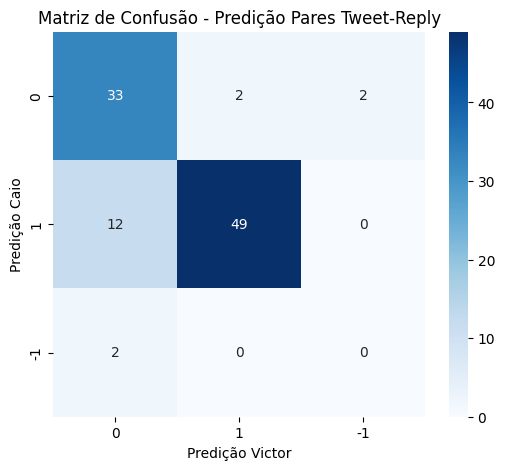

In [ ]:
labels = ["0", "1", "-1"] # classes

plt.figure(figsize=(6,5))
sns.heatmap(confusion, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels) #desenha a matriz de confusão como uma "matriz de calor"

plt.xlabel("Predição Victor")
plt.ylabel("Predição Caio")
plt.title("Matriz de Confusão - Predição Pares")
plt.show()

In [ ]:
mapa = {-1: "Indeterminado", 0: "Não Conflito", 1: "Conflito"}
mapa_tipo = {0: "Genérico", 1: "Reply", 2: "Quote"}

for i in range(len(idx_diff)):
  print("Tipo: ", mapa_tipo[int(df_caio.loc[idx_diff[i], "Class"])])
  print("Tweet 1: ", df_caio.loc[idx_diff[i], "tweet_1"])
  print("Tweet 2: ", df_caio.loc[idx_diff[i], "tweet_2"])
  print("Classificação Caio: ", mapa[int(df_caio.loc[idx_diff[i], "Conflict"])])
  print("Classificação Victor: ", mapa[int(df_victor.loc[idx_diff[i], "Conflict"])])
  print()

Tipo:  Genérico
Tweet 1:  Alguém pode me explicar quem levantou a pauta de aborto ontem? De onde surgiu e como? Eu não entendi nada, peguei o bonde andando. Só sei que #AbortoNao.
Tweet 2:  Se vc vem opinar numa tag feminina sendo contra o aborto tudo q vc disser será automaticamente anulado e a gente vai zuar com sua cara #AbortoSim
Classificação Caio:  Não Conflito
Classificação Victor:  Conflito

Tipo:  Genérico
Tweet 1:  #AbortoSim ELAS QUE DECIDEM !
Tweet 2:  Ai que inferno, é vc que está com o feto no útero, se não o #AbortoNao é da sua conta. Pelo amor
Classificação Caio:  Indeterminado
Classificação Victor:  Não Conflito

Tipo:  Genérico
Tweet 1:  “Se somos escravos do ontem, somos donos de nosso amanhã.”  #AbortoNao
Tweet 2:  o engraçado é que quando você entra no “aborto não” só tem macho escroto, querendo colocar o dedinho aonde não foi chamado. nos poupe de tanta merda. #AbortoSim
Classificação Caio:  Conflito
Classificação Victor:  Não Conflito

Tipo:  Genérico
Tweet 1:  V

In [ ]:
#CLASSIFICAÇÕES POR CLASSES CAIO
print("CLASSIFICAÇÕES POR CLASSES CAIO:")
print("Cloroquina:")
print("Conflito:", df_caio[df_caio['Conflict'] == 1].shape[0])
print("Não conflito:", df_caio[df_caio['Conflict'] == 0].shape[0])
print("Indeterminado:", df_caio[df_caio['Conflict'] == -1].shape[0])

CLASSIFICAÇÕES POR CLASSES CAIO:
Aborto:
Conflito: 61
Não conflito: 37
Indeterminado: 2


In [ ]:
#CLASSIFICAÇÕES POR CLASSES VICTOR
print("CLASSIFICAÇÕES POR CLASSES VICTOR:")
print("Cloroquina:")
print("Conflito:", df_victor[df_victor['Conflict'] == 1].shape[0])
print("Não conflito:", df_victor[df_victor['Conflict'] == 0].shape[0])
print("Indeterminado:", df_victor[df_victor['Conflict'] == -1].shape[0])

CLASSIFICAÇÕES POR CLASSES VICTOR:
Aborto:
Conflito: 51
Não conflito: 47
Indeterminado: 2


In [ ]:
#Distribuição de conflitos por classes CAIO

#Separando as classes
reply_caio = df_caio[df_caio['Class'] == 1]
quote_caio = df_caio[df_caio['Class'] == 2]
original_caio = df_caio[df_caio['Class'] == 0]
print("Distribuição de conflitos por classes CAIO:")
print("Replys anotados:", reply_caio.shape[0])
print("Conflitos:", reply_caio[reply_caio['Conflict'] == 1].shape[0])
print("Não conflitos:", reply_caio[reply_caio['Conflict'] == 0].shape[0])
print()
print("Quote anotados:", quote_caio.shape[0])
print("Conflitos:", quote_caio[quote_caio['Conflict'] == 1].shape[0])
print("Não conflitos:", quote_caio[quote_caio['Conflict'] == 0].shape[0])
print()
print("Originals anotados:", original_caio.shape[0])
print("Conflitos:", original_caio[original_caio['Conflict'] == 1].shape[0])
print("Não conflitos:", original_caio[original_caio['Conflict'] == 0].shape[0])

Distribuição de conflitos por classes CAIO:
Replys anotados: 31
Conflitos: 23
Não conflitos: 8

Quote anotados: 18
Conflitos: 12
Não conflitos: 6

Originals anotados: 51
Conflitos: 26
Não conflitos: 23


In [ ]:
#Distribuição de conflitos por classes VICTOR

#Separando as classes
reply_victor = df_victor[df_victor['Class'] == 1]
quote_victor = df_victor[df_victor['Class'] == 2]
original_victor = df_victor[df_victor['Class'] == 0]
print("Distribuição de conflitos por classes VICTOR:")
print("Replys anotados:", reply_victor.shape[0])
print("Conflitos:", reply_victor[reply_victor['Conflict'] == 1].shape[0])
print("Não conflitos:", reply_victor[reply_victor['Conflict'] == 0].shape[0])
print()
print("Quote anotados:", quote_victor.shape[0])
print("Conflitos:", quote_victor[quote_victor['Conflict'] == 1].shape[0])
print("Não conflitos:", quote_victor[quote_victor['Conflict'] == 0].shape[0])
print()
print("Originals anotados:", original_victor.shape[0])
print("Conflitos:", original_victor[original_victor['Conflict'] == 1].shape[0])
print("Não conflitos:", original_victor[original_victor['Conflict'] == 0].shape[0])

Distribuição de conflitos por classes VICTOR:
Replys anotados: 31
Conflitos: 19
Não conflitos: 12

Quote anotados: 18
Conflitos: 10
Não conflitos: 8

Originals anotados: 51
Conflitos: 22
Não conflitos: 27


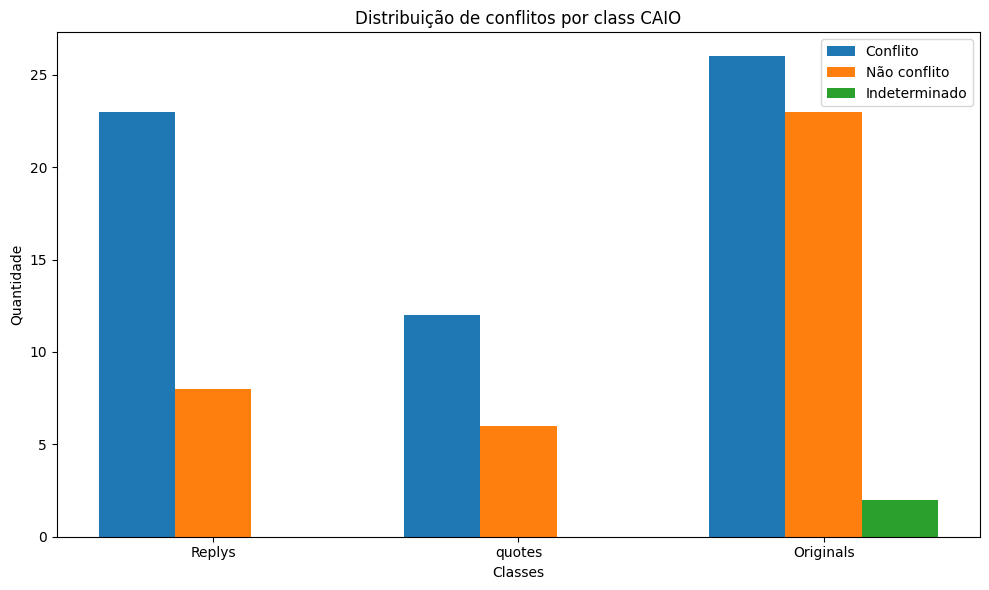

In [ ]:
# grafico
# Registando as contagens de classificações por estruturas
classes = ['Replys', 'quotes', 'Originals']

conflitos = [
    reply_caio[reply_caio['Conflict'] == 1].shape[0],
    quote_caio[quote_caio['Conflict'] == 1].shape[0],
    original_caio[original_caio['Conflict'] == 1].shape[0]
]

nao_conflitos = [
    reply_caio[reply_caio['Conflict'] == 0].shape[0],
    quote_caio[quote_caio['Conflict'] == 0].shape[0],
    original_caio[original_caio['Conflict'] == 0].shape[0]
]

indeterminados = [
    reply_caio[reply_caio['Conflict'] == -1].shape[0],
    quote_caio[quote_caio['Conflict'] == -1].shape[0],
    original_caio[original_caio['Conflict'] == -1].shape[0]
]



# Posição das barras

x = np.arange(len(classes))

largura = 0.25

#desenhando o grafico

plt.figure(figsize=(10,6))

plt.bar(x - largura, conflitos,
        width=largura,
        label='Conflito')

plt.bar(x, nao_conflitos,
        width=largura,
        label='Não conflito')

plt.bar(x + largura, indeterminados,
        width=largura,
        label='Indeterminado')

plt.xticks(x, classes)

plt.xlabel("Classes")
plt.ylabel("Quantidade")

plt.title("Distribuição de conflitos por class CAIO")

plt.legend()

plt.tight_layout()

plt.show()

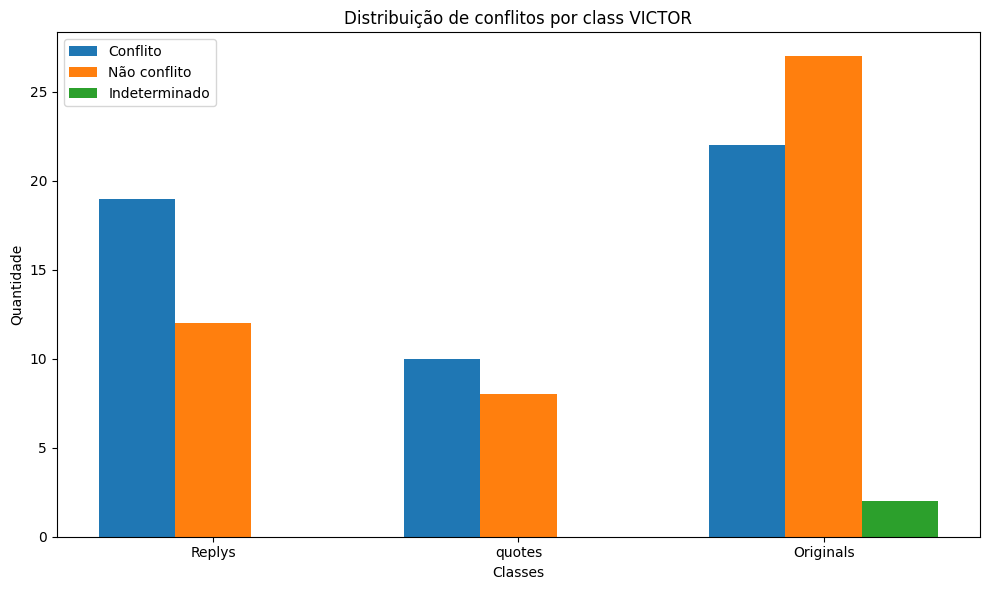

In [ ]:
# grafico
# Registando as contagens de classificações por estruturas
classes = ['Replys', 'quotes', 'Originals']

conflitos = [
    reply_victor[reply_victor['Conflict'] == 1].shape[0],
    quote_victor[quote_victor['Conflict'] == 1].shape[0],
    original_victor[original_victor['Conflict'] == 1].shape[0]
]

nao_conflitos = [
    reply_victor[reply_victor['Conflict'] == 0].shape[0],
    quote_victor[quote_victor['Conflict'] == 0].shape[0],
    original_victor[original_victor['Conflict'] == 0].shape[0]
]

indeterminados = [
    reply_victor[reply_victor['Conflict'] == -1].shape[0],
    quote_victor[quote_victor['Conflict'] == -1].shape[0],
    original_victor[original_victor['Conflict'] == -1].shape[0]
]



# Posição das barras

x = np.arange(len(classes))

largura = 0.25

#desenhando o grafico

plt.figure(figsize=(10,6))

plt.bar(x - largura, conflitos,
        width=largura,
        label='Conflito')

plt.bar(x, nao_conflitos,
        width=largura,
        label='Não conflito')

plt.bar(x + largura, indeterminados,
        width=largura,
        label='Indeterminado')

plt.xticks(x, classes)

plt.xlabel("Classes")
plt.ylabel("Quantidade")

plt.title("Distribuição de conflitos por class VICTOR")

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
# Previsoes incorretas CAIO:
df_inc_caio = df_caio[(df_caio['P(Conflict)'] > 0.5) & (df_caio['Conflict'] != 1)]
df_inc_caio.shape

(39, 6)

In [ ]:
# Previsoes incorretas VICTOR:
df_inc_victor = df_victor[(df_victor['P(Conflict)'] > 0.5) & (df_victor['Conflict'] != 1)]
df_inc_victor.shape

(49, 6)

In [ ]:
#Erros por classe de tweet CAIO
print("Erros por classe de tweet:")
print("Replys:", df_inc_caio[df_inc_caio['Class'] == 1].shape[0])
print("Quotes:", df_inc_caio[df_inc_caio['Class'] == 2].shape[0])
print("Originals:", df_inc_caio[df_inc_caio['Class'] == 0].shape[0])

Erros por classe de tweet:
Replys: 8
Quotes: 6
Originals: 25


In [ ]:
#Erros por classe de tweet VICTOR
print("Erros por classe de tweet:")
print("Replys:", df_inc_victor[df_inc_victor['Class'] == 1].shape[0])
print("Quotes:", df_inc_victor[df_inc_victor['Class'] == 2].shape[0])
print("Originals:", df_inc_victor[df_inc_victor['Class'] == 0].shape[0])

Erros por classe de tweet:
Replys: 12
Quotes: 8
Originals: 29


In [ ]:
#Organizando classificações de conflitos em quotes de Caio e Victor em um unico DF
df = df_caio.drop('Conflict', axis = 1)
df['Conflict_Caio'] = df_caio['Conflict']
df['Conflict_Victor'] = df_victor['Conflict']

In [ ]:
df

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict_Caio,Conflict_Victor
0,"Estamos em 2020 século 21, as mulheres ainda n...","Qd vc abre a hastag #AbortoNao, a unica coisa ...",0,0.029973,0.970027,0,0
1,#AbortoNao Jamais ! Sim a vida .,"Vc é contra o aborto por se declarar pró vida,...",0,0.035262,0.964738,1,1
2,#AbortoNunca ENTENDAM quando a pessoa é #Abort...,vcs falam #AbortoNao como se existisse um méto...,0,0.035714,0.964286,0,0
3,Alguém pode me explicar quem levantou a pauta ...,Se vc vem opinar numa tag feminina sendo contr...,0,0.038099,0.961901,0,1
4,Aborto não é método contraceptivo!antes de esc...,Vai caça o que fazer e deixa as mulheres escol...,1,0.038269,0.961731,1,1
...,...,...,...,...,...,...,...
95,Vc n pode ser comunista e ao mesmo tempo defen...,Muito menos se dizer cristã e feminista. #Abor...,2,0.138647,0.861353,0,0
96,#AbortoNao Aborto é caro Não quer ter filho?...,Se fosse só se preservar não haveria gravidez ...,1,0.138727,0.861273,1,1
97,"O aborto tem q ser permitido, pra evitar q cri...",""" engravida quem quer"" hmmm... sério? #AbortoSIM",2,0.142704,0.857296,0,0
98,"Todo mundo que apoiava a escravidão era livre,...",kkkkkkkkkkkkkkkkkk GENTEkkkkk o bebe sempre morre,2,0.148157,0.851843,1,1


In [ ]:
df.to_csv("aborto_induzido_classificado.csv", index=False, encoding="utf-8")
files.download("aborto_induzido_classificado.csv")

# **Criando Dataset das divergencias**

In [ ]:
div = df_caio.iloc[idx_diff].drop('Conflict', axis=1)
div['Conflict_caio'] = df_caio['Conflict'].iloc[idx_diff].astype(int)
div['Conflict_victor'] = df_victor['Conflict'].iloc[idx_diff].astype(int)
div['Conflict'] = np.nan

In [ ]:
div.shape

(18, 8)

In [ ]:
div

In [ ]:
div_cloroquina_final = div.drop(columns=['Conflict_caio', 'Conflict_victor'])
div_cloroquina_final

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
3,Alguém pode me explicar quem levantou a pauta ...,Se vc vem opinar numa tag feminina sendo contr...,0,0.038099,0.961901,NaN
7,#AbortoSim ELAS QUE DECIDEM !,"Ai que inferno, é vc que está com o feto no út...",0,0.041762,0.958238,NaN
14,"“Se somos escravos do ontem, somos donos de no...",o engraçado é que quando você entra no “aborto...,0,0.045212,0.954788,NaN
15,"Vamos ser coerentes, não faz sentido tirar a v...",#AbortoSim Mas quanta pretensão Vocês nem sa...,0,0.045375,0.954625,NaN
18,"Sem condições e acaba abandonando na rua, você...","Então vc acha q a fome, o frio, a pobreza se r...",1,0.047804,0.952196,NaN
29,#AbortoNao pela vida e para vida,n sei pq tão discutindo isso porém #AbortoSim,0,0.056636,0.943364,NaN
31,Basta de tanto sofrimento. #AbortoNAO,A partir do momento que várias mulheres morrem...,0,0.057372,0.942628,NaN
33,Fatos sobre o aborto no Brasil e no mundo que ...,na sua opinião a cabeça de alguém que aborta v...,2,0.058315,0.941685,NaN
49,hoje tá foda viu essas # de monarquiaja e abor...,Eu olhando o perfil dos acéfalos que levantam ...,0,0.076296,0.923704,NaN
50,Direito à vida #AbortoNao,não podia ir dormir sem tentar subir essa # #A...,0,0.076553,0.923447,NaN


In [ ]:
div_cloroquina_final.to_csv("divergencias_cloroquina_induzido.csv", index=False, encoding="utf-8")
files.download("divergencias_cloroquina_induzido.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Criando Dataset das Convergencias**




In [ ]:
conv_cloroquina = df_caio.drop(index=idx_diff, errors='ignore')
conv_cloroquina.shape

(82, 6)

In [ ]:
conv_aborto

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,"Estamos em 2020 século 21, as mulheres ainda n...","Qd vc abre a hastag #AbortoNao, a unica coisa ...",0,0.029973,0.970027,0
1,#AbortoNao Jamais ! Sim a vida .,"Vc é contra o aborto por se declarar pró vida,...",0,0.035262,0.964738,1
2,#AbortoNunca ENTENDAM quando a pessoa é #Abort...,vcs falam #AbortoNao como se existisse um méto...,0,0.035714,0.964286,0
4,Aborto não é método contraceptivo!antes de esc...,Vai caça o que fazer e deixa as mulheres escol...,1,0.038269,0.961731,1
5,Pelo simples fato de que matar uma vida humana...,@ Vida é a partir do embrião.E embrião é vida....,1,0.040479,0.959521,1
...,...,...,...,...,...,...
95,Vc n pode ser comunista e ao mesmo tempo defen...,Muito menos se dizer cristã e feminista. #Abor...,2,0.138647,0.861353,0
96,#AbortoNao Aborto é caro Não quer ter filho?...,Se fosse só se preservar não haveria gravidez ...,1,0.138727,0.861273,1
97,"O aborto tem q ser permitido, pra evitar q cri...",""" engravida quem quer"" hmmm... sério? #AbortoSIM",2,0.142704,0.857296,0
98,"Todo mundo que apoiava a escravidão era livre,...",kkkkkkkkkkkkkkkkkk GENTEkkkkk o bebe sempre morre,2,0.148157,0.851843,1


In [ ]:
#juntando anotações do professor (QUANDO ELE ANOTAR)
#adicionando as classificações do professor
# file_class_prof = "1FSUrpSaiBAp5Gho-CsEw6kse3q4wCB8B"
# url = f"https://drive.google.com/uc?id={file_class_prof}"
# gdown.download(url, "class_prof.csv", quiet=False)
# df_class_prof = pd.read_csv ("class_prof.csv")

In [ ]:
# df_class_prof

In [ ]:
# df_desempate = div.iloc[:len(df_class_prof)-1,:]
# df_desempate

In [ ]:
# df_desempate['Conflict_prof'] = df_class_prof['Conflict']
# df_desempate

In [ ]:
# def resolver_conflito(row):
#     prof = row['Conflict_prof']
#     caio = row['Conflict_caio']
#     victor = row['Conflict_victor']

#     if prof == caio or prof == victor:
#         return prof
#     else:
#         return -1

# df_desempate['Conflict'] = df_desempate.apply(resolver_conflito, axis=1)

In [ ]:
# df_desempate = df_desempate.drop(columns=['Conflict_caio', 'Conflict_victor', 'Conflict_prof'])
# df_desempate

In [ ]:
# conv_cloroquina = pd.concat([conv_cloroquina, df_desempate], ignore_index=True, axis = 0)
# conv_cloroquina

In [ ]:
conv_cloroquina.to_csv("convergencias_cloroquina_induzido.csv", index=False, encoding="utf-8")
files.download("convergencias_cloroquina_induzido.csv")